In [ ]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [171]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df.set_index('DATE', inplace=True)
print(df.head)



<bound method NDFrame.head of             PRCP  SNOW  SNWD  TMIN  TMAX
DATE                                    
01-01-1869  0.75   9.0   NaN  19.0  29.0
01-02-1869  0.03   0.0   NaN  21.0  27.0
01-03-1869  0.00   0.0   NaN  27.0  35.0
01-04-1869  0.18   0.0   NaN  34.0  37.0
01-05-1869  0.05   0.0   NaN  37.0  43.0
...          ...   ...   ...   ...   ...
12-25-2022  0.00   0.0   0.0  14.0  28.0
12-26-2022  0.00   0.0   0.0  18.0  29.0
12-27-2022  0.00   0.0   0.0  29.0  35.0
12-28-2022  0.00   0.0   0.0  33.0  47.0
12-29-2022  0.00   0.0   0.0  40.0  51.0

[56245 rows x 5 columns]>


7
0
DATE
01-01-1869    24.0
01-02-1869    24.0
01-03-1869    31.0
01-04-1869    35.5
01-05-1869    40.0
Name: Temp, dtype: float64


<Axes: xlabel='DATE'>

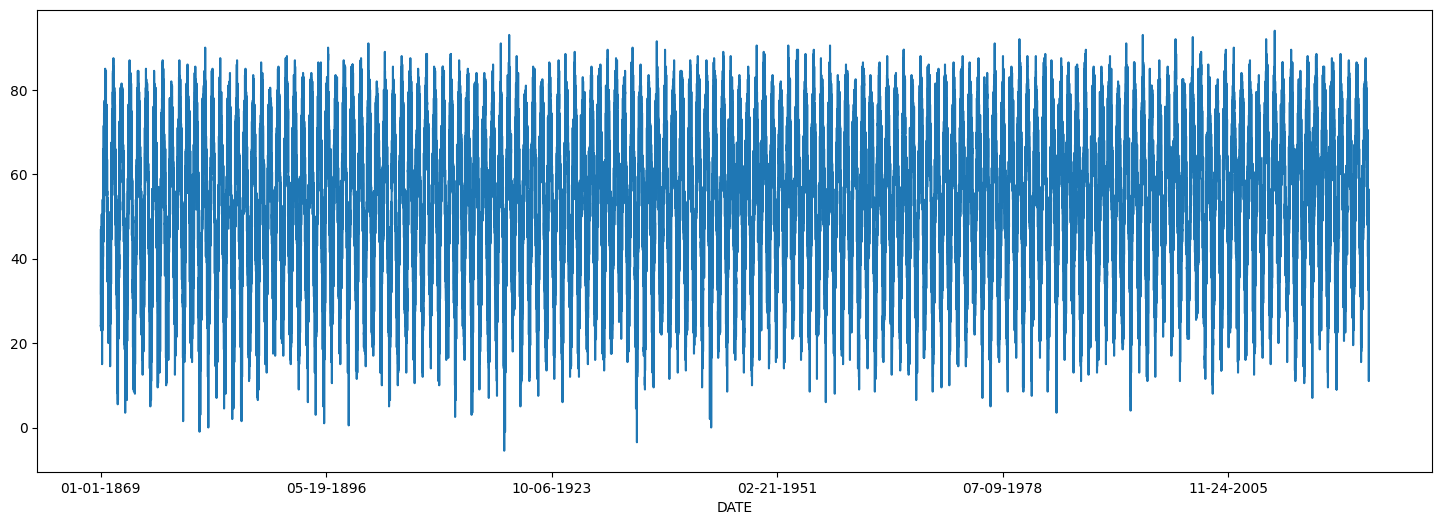

In [172]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
print(temp.isna().sum())
temp = temp.ffill()
print(temp.isna().sum())
print(temp.head())

temp.plot(figsize=(18, 6))


In [173]:
def df_to_array(df, window_size):
    df_as_np=df.to_numpy()
    print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)


WINDOW_SIZE=60
X, y =df_to_array(temp, WINDOW_SIZE)
X.shape, y.shape


[24.  24.  31.  ... 32.  40.  45.5]


((56185, 60, 1), (56185,))

In [ ]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

[52.5 47.5 39.5 ... 32.  40.  45.5]


In [175]:
from tensorflow.keras.models import Sequential              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [176]:
model1=Sequential()
model1.add(InputLayer((WINDOW_SIZE, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))
model1.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [177]:
cp=ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp])

Epoch 1/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 1902.1271 - root_mean_squared_error: 43.6134 - val_loss: 1010.3845 - val_root_mean_squared_error: 31.7865
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 554.3868 - root_mean_squared_error: 23.5454 - val_loss: 273.8565 - val_root_mean_squared_error: 16.5486
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 138.7630 - root_mean_squared_error: 11.7798 - val_loss: 69.0706 - val_root_mean_squared_error: 8.3109
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 46.5701 - root_mean_squared_error: 6.8242 - val_loss: 35.1510 - val_root_mean_squared_error: 5.9288
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 33.5234 - root_mean_squared_error: 5.7899 - val_loss: 30.4490 - val_root_mean_squared_error: 5.5181
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 31.2395 - root_mean_squared_error: 5.5892 - val_loss: 28.8907 - val_root_mean_squared_error: 5.3750
Epoc

In [179]:
from tensorflow.keras.models import load_model
model1=load_model('model1.keras')

In [180]:
train_predicions=model1.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


,Train Predictions,Actuals
0,20.164211,27.5
1,34.143135,35.5
2,34.462040,31.5
3,30.556566,23.0
4,24.089863,28.0
...,...,...
45995,35.639858,18.0
45996,18.373529,13.0
45997,21.234905,20.0
45998,26.078592,23.0


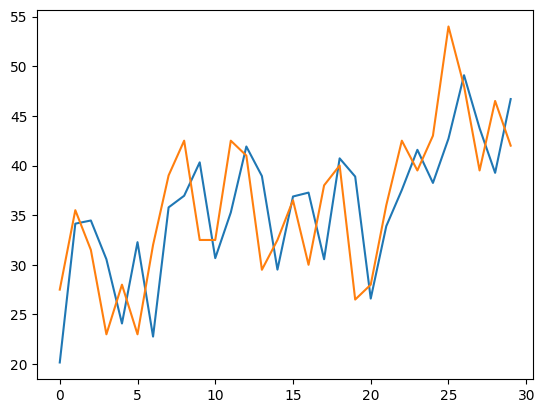

In [181]:
plt.plot(train_results["Train Predictions"][:30])
plt.plot(train_results["Actuals"][:30])


In [182]:
val_predicions=model1.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


,Validation Predictions,Actuals
0,25.515293,33.5
1,35.074070,38.0
2,35.090813,19.5
3,17.995155,20.0
4,27.424187,27.0
...,...,...
5145,37.306156,33.5
5146,37.900066,41.5
5147,44.062191,46.5
5148,45.648342,43.5


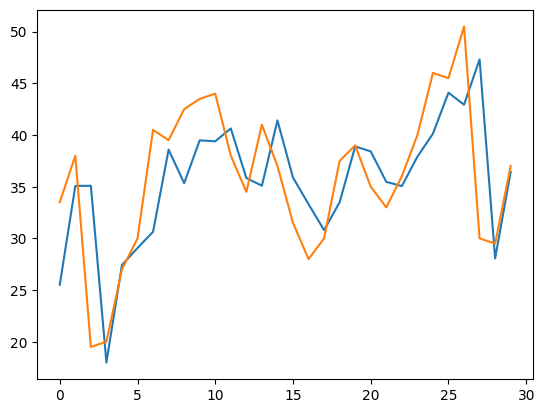

In [183]:
plt.plot(val_results["Validation Predictions"][:30])
plt.plot(val_results["Actuals"][:30])

In [184]:
test_predictions=model1.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
test_results


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Test Predictions,Actuals
0,45.908535,52.5
1,50.391788,47.5
2,45.898151,39.5
3,40.986435,40.0
4,43.244267,44.5
...,...,...
5030,16.175659,21.0
5031,31.837780,23.5
5032,25.051563,32.0
5033,36.256931,40.0


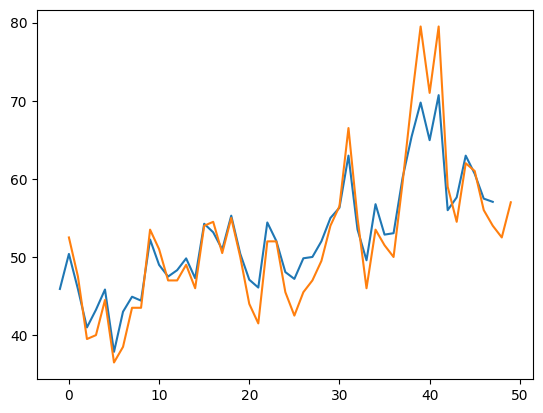

In [185]:

plt.plot(range(-1, -1+len(test_results["Test Predictions"][:49])),test_results["Test Predictions"][:49])
plt.plot(test_results["Actuals"][:50])


In [199]:
next_100_years=pd.date_range(
    start="01-01-2023",
    periods=36500,
    freq='D'
)
print(next_100_years)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2122-11-28', '2122-11-29', '2122-11-30', '2122-12-01',
               '2122-12-02', '2122-12-03', '2122-12-04', '2122-12-05',
               '2122-12-06', '2122-12-07'],
              dtype='datetime64[us]', length=36500, freq='D')


In [204]:
X2, y2=df_to_array(next_100_years, WINDOW_SIZE)
#future_predictions=model1.predict(X2).flatten()
#future_results=pd.DataFrame(data={'Futre Dates Predictions': future_predictions})
X_test


['2023-01-01T00:00:00.000000' '2023-01-02T00:00:00.000000'
 '2023-01-03T00:00:00.000000' ... '2122-12-05T00:00:00.000000'
 '2122-12-06T00:00:00.000000' '2122-12-07T00:00:00.000000']


array([[[14. ],
        [28.5],
        [29.5],
        ...,
        [46.5],
        [43.5],
        [45.5]],

       [[28.5],
        [29.5],
        [24. ],
        ...,
        [43.5],
        [45.5],
        [52.5]],

       [[29.5],
        [24. ],
        [21.5],
        ...,
        [45.5],
        [52.5],
        [47.5]],

       ...,

       [[50.5],
        [50.5],
        [53. ],
        ...,
        [11. ],
        [21. ],
        [23.5]],

       [[50.5],
        [53. ],
        [58. ],
        ...,
        [21. ],
        [23.5],
        [32. ]],

       [[53. ],
        [58. ],
        [63. ],
        ...,
        [23.5],
        [32. ],
        [40. ]]], shape=(5035, 60, 1))